C:\Users\Ghiffari\AppData\Local\Temp\ipykernel_2644\3166504253.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Ghiffari\AppData\Local\Temp\ipykernel_2644\3166504253.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{int(x)} lantai" for x in median_area["stories"]])


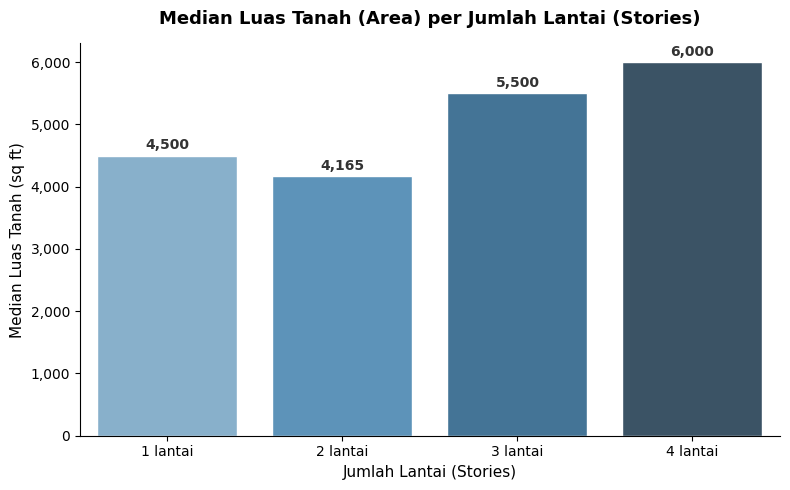

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

"""Hitung median luas tanah (area) berdasarkan jumlah tingkat lantai rumah (stories). Tampilkan dalam Bar Chart."""

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv("Kelas C_Housing.csv")

# ── Agregasi: median luas tanah per jumlah lantai ─────────────────────────────
median_area = (
    df.groupby("stories")["area"]
    .median()
    .reset_index()
    .rename(columns={"area": "median_area"})
    .sort_values("stories")
)

# ── Plot (pendekatan objek) ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=median_area,
    x="stories",
    y="median_area",
    palette="Blues_d",
    edgecolor="white",
    ax=ax,          # <-- objek axes dioper langsung ke seaborn
)

# Anotasi nilai di atas setiap bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#333333",
    )

# Label & styling
ax.set_title("Median Luas Tanah (Area) per Jumlah Lantai (Stories)", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Jumlah Lantai (Stories)", fontsize=11)
ax.set_ylabel("Median Luas Tanah (sq ft)", fontsize=11)
ax.set_xticklabels([f"{int(x)} lantai" for x in median_area["stories"]])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig("kategori_A_median_area_per_stories.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0